<a href="https://colab.research.google.com/github/SruthiGS-Gito/Online-News-Popularity-Prediction/blob/feature%2Fdecision-tree-regression/Online_News_Popularity_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split, KFold,cross_val_score, GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, AdaBoostRegressor
# for evaluvation
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, accuracy_score

# Used by RandomizedSearchCV to sample random integer values from a uniform distribution for hyperparameters
from scipy.stats import randint

# Reading Dataset

In [4]:
# filepath to the csv file
filepath = '/content/drive/MyDrive/Colab Notebooks/OnlineNewsPopularity.csv'

# Reading dataset and assigning the df created to a variable so as to store it
df_news = pd.read_csv(filepath)
df_news.columns = df_news.columns.str.strip()
df_news.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


# EDA

In [5]:
df_news.shape

(39644, 61)

In [6]:
df_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            39644 non-null  object 
 1   timedelta                      39644 non-null  float64
 2   n_tokens_title                 39644 non-null  float64
 3   n_tokens_content               39644 non-null  float64
 4   n_unique_tokens                39644 non-null  float64
 5   n_non_stop_words               39644 non-null  float64
 6   n_non_stop_unique_tokens       39644 non-null  float64
 7   num_hrefs                      39644 non-null  float64
 8   num_self_hrefs                 39644 non-null  float64
 9   num_imgs                       39644 non-null  float64
 10  num_videos                     39644 non-null  float64
 11  average_token_length           39644 non-null  float64
 12  num_keywords                   39644 non-null 

In [7]:
df_news.describe()

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,...,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,354.530471,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,...,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,214.163767,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,...,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,164.000000,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,...,0.050000,0.600000,-0.328383,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000,946.000000
50%,339.000000,10.000000,409.000000,0.539226,1.000000,0.690476,8.000000,3.000000,1.000000,0.000000,...,0.100000,0.800000,-0.253333,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000,1400.000000
75%,542.000000,12.000000,716.000000,0.608696,1.000000,0.754630,14.000000,4.000000,4.000000,1.000000,...,0.100000,1.000000,-0.186905,-0.300000,-0.050000,0.500000,0.150000,0.500000,0.250000,2800.000000
max,731.000000,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000


In [8]:
df_news.isnull().sum()

,0
url,0
timedelta,0
n_tokens_title,0
n_tokens_content,0
n_unique_tokens,0
...,...
title_subjectivity,0
title_sentiment_polarity,0
abs_title_subjectivity,0
abs_title_sentiment_polarity,0


In [9]:
df_news.duplicated().sum()

np.int64(0)

In [10]:
# "url" is an article link and "timedelta" is days since published, both doesn't predict news popularity hence Drop
df_news.drop(columns = ["url", "timedelta"], inplace = True)
df_news.head()

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [11]:
num_cols = []
cat_cols = []

In [12]:
num_cols = df_news.select_dtypes(include = ['int','float']).columns
num_cols

Index(['n_tokens_title', 'n_tokens_content', 'n_unique_tokens',
       'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs',
       'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length',
       'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
       'global_rate_negat

In [13]:
cat_cols = df_news.select_dtypes(include = ['object']).columns
cat_cols    # empty hence no encoding required

Index([], dtype='object')

### Correlation & Mutual Information

In [14]:
# correlation gives linear relationships with "shares"
corr_with_target = df_news.corr()['shares'].sort_values(ascending=False)
corr_with_target

,shares
shares,1.000000
kw_avg_avg,0.110413
LDA_03,0.083771
kw_max_avg,0.064306
self_reference_avg_sharess,0.057789
self_reference_min_shares,0.055958
self_reference_max_shares,0.047115
num_hrefs,0.045404
kw_avg_max,0.044686
kw_min_avg,0.039551


In [15]:
X_temp = df_news.drop(columns = ["shares"])
y_temp = df_news["shares"]

# mutual_info_regression is used because our target column "shares" has numeric/continous values
mi_scores = mutual_info_regression(X_temp, y_temp, random_state = 42)
# for "number to its features mapping" we use pd.Series()
mi_series = pd.Series(mi_scores, index = X_temp.columns).sort_values(ascending = False)
mi_series

,0
kw_max_avg,0.041891
self_reference_min_shares,0.039458
self_reference_max_shares,0.037679
LDA_02,0.036412
self_reference_avg_sharess,0.035820
kw_avg_avg,0.033368
LDA_00,0.030797
kw_min_avg,0.026560
LDA_03,0.026003
LDA_01,0.018558


### Plots

In [16]:
# selecting key columns to analyze
key_cols = mi_series.head(10).index.tolist()
key_cols

['kw_max_avg',
 'self_reference_min_shares',
 'self_reference_max_shares',
 'LDA_02',
 'self_reference_avg_sharess',
 'kw_avg_avg',
 'LDA_00',
 'kw_min_avg',
 'LDA_03',
 'LDA_01']

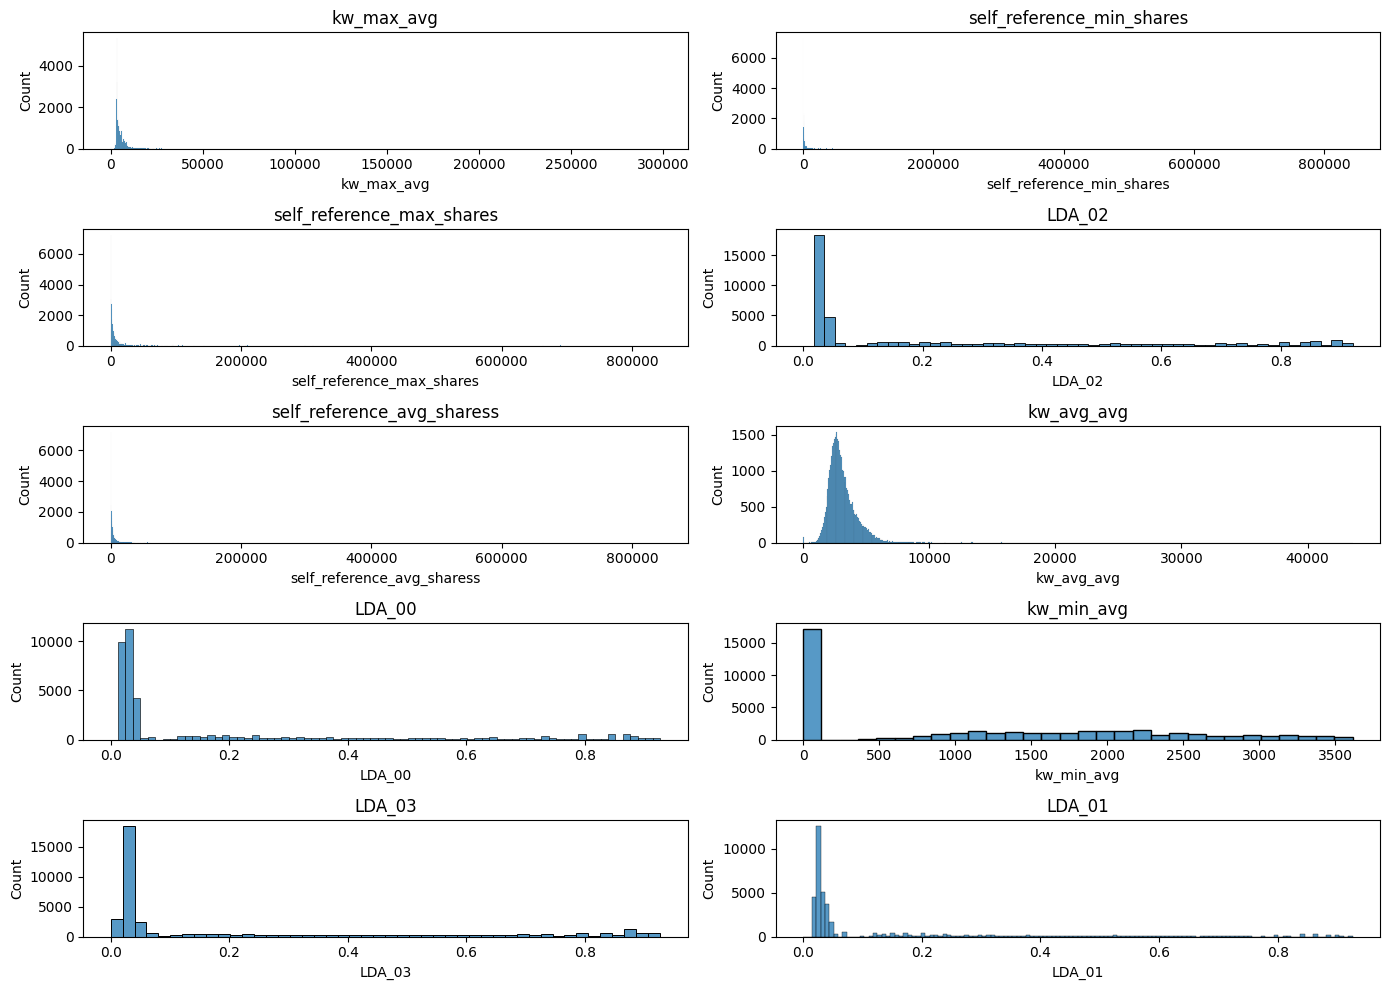

In [17]:
# plotting distribution of each key column using histograms
plt.figure(figsize=(14,10))
for i, col in enumerate(key_cols):
    plt.subplot(5, 2, i+1)
    sns.histplot(df_news[col]) # shows spread/skeweness of each variable
    plt.title(col)

plt.tight_layout()
plt.show()

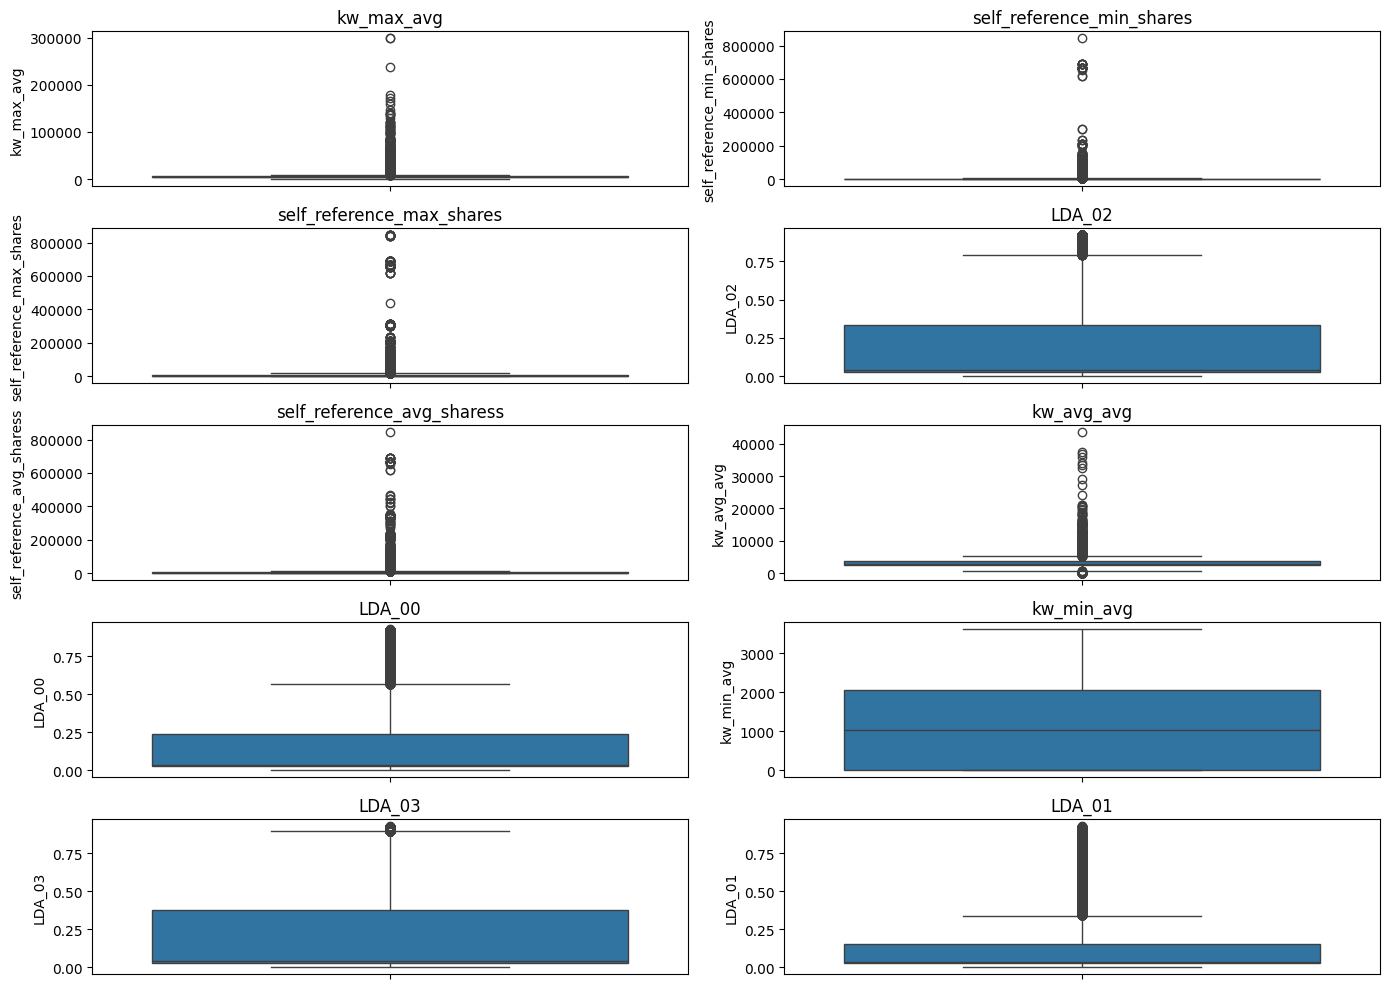

In [18]:
# plotting boxplots to check for outliers in each column
plt.figure(figsize=(14,10))
for i, col in enumerate(key_cols):
    plt.subplot(5, 2, i+1)
    sns.boxplot(df_news[col].dropna())   # highlights outliers beyond whiskers
    plt.title(col)

plt.tight_layout()
plt.show()

# PreProcessing

## Data cleaning

### Missing Value Handling

In [19]:
# There is no missing values to be handled.

### Outlier Handling

In [20]:
out_cols = [col for col in key_cols if col != 'shares']
out_cols

['kw_max_avg',
 'self_reference_min_shares',
 'self_reference_max_shares',
 'LDA_02',
 'self_reference_avg_sharess',
 'kw_avg_avg',
 'LDA_00',
 'kw_min_avg',
 'LDA_03',
 'LDA_01']

In [21]:
for col in out_cols:
    Q1 = df_news[col].quantile(0.25)
    Q3 = df_news[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_news[col] = np.where(df_news[col] < lower, lower, df_news[col])
    df_news[col] = np.where(df_news[col] > upper, upper, df_news[col])

### Duplicates Removal

In [22]:
# There is no duplicates to remove

### Data Split

In [23]:
# split before scaling to prevent data leakage
X = df_news.drop(columns = ["shares"])
y = df_news["shares"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Data Transformation

### Scaling

In [24]:
# StandardScaler() uses mean as 0 and std as 1, Data is skewed with outliers and since min-max is sensitive to outliers we use StandardScaler()
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)     # fits only on train data
X_test = scaler.transform(X_test)       # transforms test using train's data

### Encoding

In [25]:
# No categorical columns after dropping 'url' hence nothing to encode

# Model Building

## Decision Tree

In [26]:
### DECISION TREE
#********************
# build model object
dec_tree_obj = DecisionTreeRegressor()

# train model
dec_tree_obj.fit(X_train, y_train)

# make predictions using the model
y_pred_tree = dec_tree_obj.predict(X_test)

# evaluate model performance
dt_mae = mean_absolute_error(y_test, y_pred_tree)
dt_mse = mean_squared_error(y_test, y_pred_tree)
dt_rmse = root_mean_squared_error(y_test, y_pred_tree)

print("Mean absolute error (DT) : ", dt_mae)
print("Mean squared error (DT) : ", dt_mse)
print("Root mean squared error (DT) : ", dt_rmse)

Mean absolute error (DT) :  4617.25476100391
Mean squared error (DT) :  413510042.4584437
Root mean squared error (DT) :  20334.946335273267


# Cross - Validation

## K-fold

In [34]:
from sklearn.tree import DecisionTreeRegressor

kf_obj = KFold(n_splits = 4, shuffle = True, random_state= 42)
scores = cross_val_score(
    DecisionTreeRegressor(),
    X,
    y,
    cv = kf_obj,
    scoring = 'r2'
  )
print('For Decision Tree model')
print("cross validation scores:", scores)
print("mean of cv scores:", scores.mean())


For Decision Tree model
cross validation scores: [-1.60762643 -0.58826961 -1.2431263  -2.04374963]
mean of cv scores: -1.37069299242201


## Grid Search

In [28]:


# Define the parameter grid for DecisionTreeRegressor
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],   # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]      # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_dt,
    cv=kf_obj, # Using the kf_obj defined earlier for consistency
    scoring='neg_mean_absolute_error', # Optimize for MAE
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_dt.fit(X_train, y_train)

# Print the best parameters and best MAE score
print("Best parameters for Decision Tree Regressor (Grid Search):", grid_search_dt.best_params_)
print("Best MAE (Grid Search):", -grid_search_dt.best_score_)

Fitting 4 folds for each of 45 candidates, totalling 180 fits
Best parameters for Decision Tree Regressor (Grid Search): {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best MAE (Grid Search): 3143.913640884855


After finding the best hyperparameters, let's train a new model with these parameters and evaluate its performance on the test set.

In [29]:
# Get the best model from Grid Search
best_dt_model = grid_search_dt.best_estimator_

# Make predictions on the test set
y_pred_dt_modf = best_dt_model.predict(X_test)

# Evaluate the tuned model
dt_mae_modf = mean_absolute_error(y_test, y_pred_dt_modf)
dt_mse_modf = mean_squared_error(y_test, y_pred_dt_modf)
dt_rmse_modf = root_mean_squared_error(y_test, y_pred_dt_modf)

print("Mean absolute error (Tuned DT) : ", dt_mae_modf)
print("Mean squared error (Tuned DT) : ", dt_mse_modf)
print("Root mean squared error (Tuned DT) : ", dt_rmse_modf)

Mean absolute error (Tuned DT) :  3065.9824872555323
Mean squared error (Tuned DT) :  128989020.10632284
Root mean squared error (Tuned DT) :  11357.333318447727


## Random Search

In [30]:
# Define the parameter distribution for DecisionTreeRegressor for Randomized Search
param_dist_dt = {
    'max_depth': randint(3, 20),  # Max depth between 3 and 20
    'min_samples_split': randint(2, 20),  # Min samples split between 2 and 20
    'min_samples_leaf': randint(1, 10)  # Min samples leaf between 1 and 10
}

# Initialize RandomizedSearchCV
random_search_dt = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_distributions=param_dist_dt,
    n_iter=50,  # Number of parameter settings that are sampled
    cv=kf_obj,  # Using the kf_obj defined earlier for consistency
    scoring='neg_mean_absolute_error',  # Optimize for MAE
    random_state=42,
    n_jobs=-1,  # Use all available cores
    verbose=1
)

# Fit RandomizedSearchCV to the training data
random_search_dt.fit(X_train, y_train)

# Print the best parameters and best MAE score
print("Best parameters for Decision Tree Regressor (Random Search):", random_search_dt.best_params_)
print("Best MAE (Random Search):", -random_search_dt.best_score_)

Fitting 4 folds for each of 50 candidates, totalling 200 fits
Best parameters for Decision Tree Regressor (Random Search): {'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 6}
Best MAE (Random Search): 3153.754952815342


# Ensemble Models

## Bagging

In [31]:
# build model object
bagging_model = BaggingRegressor(estimator = DecisionTreeRegressor(random_state=42),
                                  n_estimators = 10,
                                  max_samples = 0.6,
                                  random_state=42)
# train model
bagging_model.fit(X_train, y_train)
# make predictions using the model
y_pred_bag = bagging_model.predict(X_test)
# evaluate model performance
bagging_mae = mean_absolute_error(y_test, y_pred_bag)
bagging_mse = mean_squared_error(y_test, y_pred_bag)
bagging_rmse = root_mean_squared_error(y_test, y_pred_bag)

print("Mean absolute error (Bagging) : ", bagging_mae)
print("Mean squared error (Bagging) : ", bagging_mse)
print("Root mean squared error (Bagging) : ", bagging_rmse)

Mean absolute error (Bagging) :  3643.1005423130287
Mean squared error (Bagging) :  139534075.93896836
Root mean squared error (Bagging) :  11812.454272460416


## Boosting

In [32]:

# build the model object
ada_boost_model = AdaBoostRegressor(estimator = DecisionTreeRegressor(random_state=42),
                                     n_estimators = 20,
                                     learning_rate = 1,
                                     random_state=42)
# train model
ada_boost_model.fit(X_train, y_train)

# make predictions using the model
ada_pred = ada_boost_model.predict(X_test)

# evaluate model performance
ada_mae = mean_absolute_error(y_test, ada_pred)
ada_mse = mean_squared_error(y_test, ada_pred)
ada_rmse = root_mean_squared_error(y_test, ada_pred)

print("Mean absolute error (AdaBoost) : ", ada_mae)
print("Mean squared error (AdaBoost) : ", ada_mse)
print("Root mean squared error (AdaBoost) : ", ada_rmse)

Mean absolute error (AdaBoost) :  2403.6656577121958
Mean squared error (AdaBoost) :  120120829.26358935
Root mean squared error (AdaBoost) :  10959.964838610997


##